Generating GIF... This might take a few seconds.
Success! Saved as 'random_walk.gif' in your current directory.


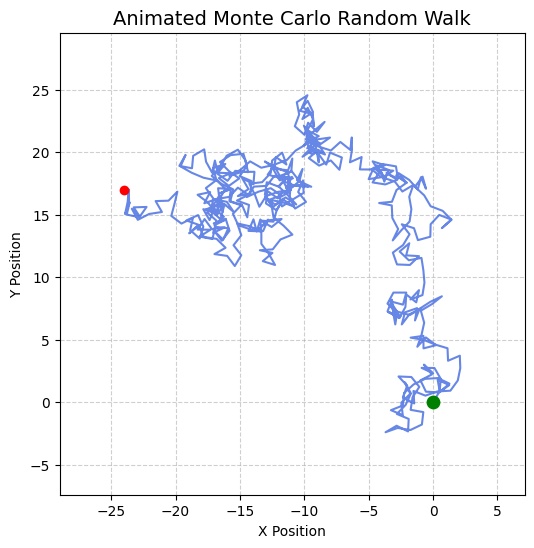

In [3]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Set the number of steps (reduced to 500 for a reasonable GIF size)
num_steps = 500

# Initialize arrays to hold the x and y coordinates
x = np.zeros(num_steps)
y = np.zeros(num_steps)

# Run the random walk loop to calculate all positions first
for i in range(1, num_steps):
    # Pick a random direction (angle in radians)
    angle = np.random.uniform(0, 2 * np.pi)
    
    # Calculate the new position
    x[i] = x[i-1] + np.cos(angle)
    y[i] = y[i-1] + np.sin(angle)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Set fixed axis limits based on the min/max of the generated walk so the camera doesn't jump
buffer = 5
ax.set_xlim(np.min(x) - buffer, np.max(x) + buffer)
ax.set_ylim(np.min(y) - buffer, np.max(y) + buffer)

# Add styling and labels
ax.set_title("Animated Monte Carlo Random Walk", fontsize=14)
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.grid(True, linestyle='--', alpha=0.6)

# Initialize the empty plot elements we will update each frame
line, = ax.plot([], [], color='royalblue', alpha=0.8, linewidth=1.5)
current_dot, = ax.plot([], [], 'ro', markersize=6) # Red dot for the current position
start_dot = ax.scatter(x[0], y[0], color='green', s=80, zorder=5) # Green dot for start

# Initialization function required for FuncAnimation
def init():
    line.set_data([], [])
    current_dot.set_data([], [])
    return line, current_dot

# Update function that gets called for every frame
def update(frame):
    # Draw the path up to the current frame step
    line.set_data(x[:frame], y[:frame])
    # Move the red dot to the leading edge of the path
    current_dot.set_data([x[frame]], [y[frame]])
    return line, current_dot

# Create the animation object
# interval=20 means 20ms between frames during playback
anim = animation.FuncAnimation(fig, update, frames=num_steps, 
                               init_func=init, blit=True, interval=20)

# Save the animation as a GIF using the Pillow writer
print("Generating GIF... This might take a few seconds.")
anim.save('random_walk.gif', writer='pillow', fps=30)
print("Success! Saved as 'random_walk.gif' in your current directory.")

Generating GIF... This will take approximately 9.0 seconds of render time.
Success! Saved as 'scattering_comparison_inverted.gif' in your current directory.


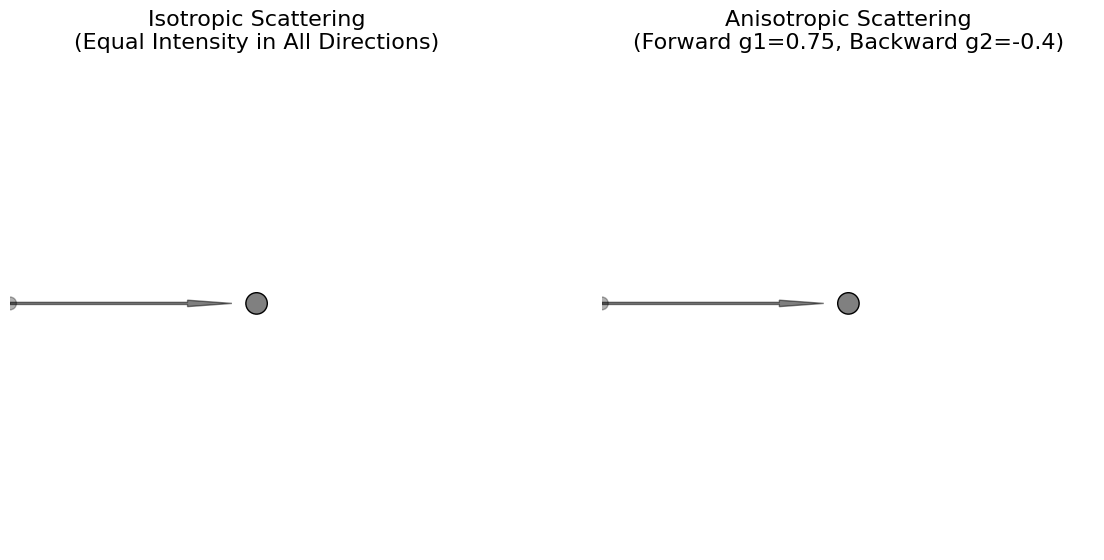

In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# --- Configuration ---
NUM_RAYS = 250        # Total number of rays visually plotted in each frame
G1_VALUE = 0.75       # Forward scattering parameter (>0 is forward)
G2_VALUE = -0.4       # Backward scattering parameter (<0 is backward)
F_WEIGHT = 0.7        # Fraction of the forward lobe (0 to 1)
RAY_MAX_LENGTH = 10.0 # Maximum radius of expansion
FPS = 30              # Frames per second for the animation
PULSE_DURATION_S = 3  # Duration of one pulse expansion cycle in seconds
NUM_PULSES = 3        # Number of times the animation expands before stopping

TOTAL_FRAMES = FPS * PULSE_DURATION_S * NUM_PULSES

# Default style provides a white background with black text
plt.style.use('default')

# Setup Figure and Subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 7))
#fig.suptitle("Visualizing Light Scattering Distributions", fontsize=20, y=0.98)

# Pre-set limits so the 'camera' doesn't zoom
limit = RAY_MAX_LENGTH * 1.15
for ax in axs:
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal') # Ensure circles appear as circles
    ax.axis('off')         # Hide axes for a clean visual

# Label each subplot
title_iso = "Isotropic Scattering\n(Equal Intensity in All Directions)"
title_aniso = f"Anisotropic Scattering\n(Forward g1={G1_VALUE}, Backward g2={G2_VALUE})"

axs[0].set_title(title_iso, fontsize=16)
axs[1].set_title(title_aniso, fontsize=16)

# Generate uniform angular grid for all 360 degrees
angles_full = np.linspace(0, 2*np.pi, NUM_RAYS, endpoint=False)

# --- Pre-calculate static visual elements ---

# Incoming light beam (for context)
for ax in axs:
    ax.add_patch(plt.Circle((-limit, 0), 0.3, color='black', alpha=0.3)) # Start of beam
    ax.add_patch(plt.Arrow(-limit, 0, limit*0.9, 0, width=0.5, color='black', alpha=0.5)) # Arrow path

# The scatterer particle (e.g., dust grain or atom) at the center
for ax in axs:
    ax.add_patch(plt.Circle((0, 0), 0.5, facecolor='gray', edgecolor='black', linewidth=1, zorder=10))

# --- Pre-calculate the Anisotropic Phase Function shape ---

def double_henyey_greenstein(g1, g2, f, theta):
    """Calculates the two-term Henyey-Greenstein probability density.
    Combines a forward lobe (g1) and a backward lobe (g2)."""
    
    def single_hg(g, th):
        if abs(g) < 1e-4:
            return np.ones_like(th)
        numerator = 1 - g**2
        denominator = (1 + g**2 - 2 * g * np.cos(th))**(1.5)
        return numerator / denominator

    prob = f * single_hg(g1, theta) + (1 - f) * single_hg(g2, theta)
    
    # Normalize prob to 0->1 range for visual scaling
    return (prob - prob.min()) / (prob.max() - prob.min())

# Calculate the Two-Term Henyey-Greenstein shape
anisotropic_lengths_weights = double_henyey_greenstein(G1_VALUE, G2_VALUE, F_WEIGHT, angles_full)

# The core animation function called for every frame
def update(frame):
    
    # Determine progress (0.0 to 1.0) within a single pulse cycle
    frames_per_pulse = FPS * PULSE_DURATION_S
    frame_in_pulse = frame % frames_per_pulse
    t = frame_in_pulse / frames_per_pulse # normalized time 0.0->1.0
    
    # Calculate smooth alpha (visibility) and current ray length scale
    alpha = np.sin(np.pi * t)
    r_current = t * RAY_MAX_LENGTH

    # --- Update Isotropic Subplot (Left) ---
    axs[0].clear()
    axs[0].axis('off')
    axs[0].set_aspect('equal')
    axs[0].set_xlim(-limit, limit)
    axs[0].set_ylim(-limit, limit)
    axs[0].set_title(title_iso, fontsize=16)
    
    axs[0].add_patch(plt.Circle((-limit, 0), 0.3, color='black', alpha=0.3))
    axs[0].add_patch(plt.Arrow(-limit, 0, limit*0.9, 0, width=0.5, color='black', alpha=0.5))
    axs[0].add_patch(plt.Circle((0, 0), 0.5, facecolor='gray', edgecolor='black', linewidth=1, zorder=10))

    for angle in angles_full:
        x_end = r_current * np.cos(angle)
        y_end = r_current * np.sin(angle)
        axs[0].plot([0, x_end], [0, y_end], color='black', alpha=alpha*0.6, linewidth=1.0)
    
    # --- Update Anisotropic Subplot (Right) ---
    axs[1].clear()
    axs[1].axis('off')
    axs[1].set_aspect('equal')
    axs[1].set_xlim(-limit, limit)
    axs[1].set_ylim(-limit, limit)
    axs[1].set_title(title_aniso, fontsize=16)
    
    axs[1].add_patch(plt.Circle((-limit, 0), 0.3, color='black', alpha=0.3))
    axs[1].add_patch(plt.Arrow(-limit, 0, limit*0.9, 0, width=0.5, color='black', alpha=0.5))
    axs[1].add_patch(plt.Circle((0, 0), 0.5, facecolor='gray', edgecolor='black', linewidth=1, zorder=10))

    for angle, weight in zip(angles_full, anisotropic_lengths_weights):
        # Apply a minimum weight so the back lobe is clearly visible
        visual_weight = weight * 0.9 + 0.1
        x_end = r_current * visual_weight * np.cos(angle)
        y_end = r_current * visual_weight * np.sin(angle)
        
        axs[1].plot([0, x_end], [0, y_end], color='black', alpha=alpha*0.6, linewidth=1.0)
    
    return axs

# Create the animation object
anim = animation.FuncAnimation(fig, update, frames=TOTAL_FRAMES, interval=1000/FPS, blit=False)

# Save the animation as a GIF
save_filename = 'scattering_comparison_inverted.gif'
print(f"Generating GIF... This will take approximately {TOTAL_FRAMES/FPS} seconds of render time.")
anim.save(save_filename, writer='pillow', fps=FPS)
print(f"Success! Saved as '{save_filename}' in your current directory.")